In [2]:
import numpy as np
import pyroomacoustics as pra
import matplotlib.pyplot as plt
from scipy.linalg import eig

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

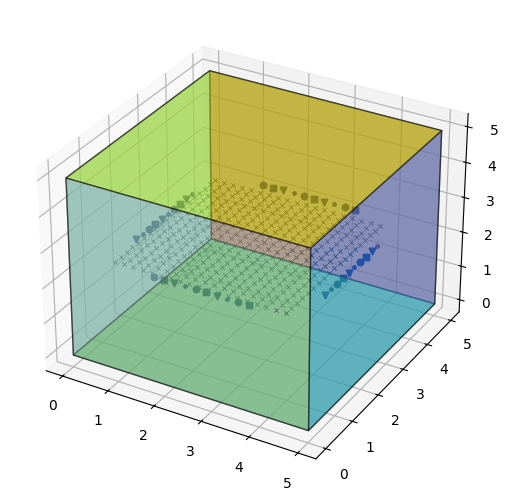

In [ ]:
# Create room object
fs = 16000   # Sampling freq. of the played audio
room_dim = [5.0, 5.0, 5.0]
max_order = 3
air_absorption = True
room = pra.ShoeBox(room_dim, fs=fs, max_order=max_order, air_absorption=air_absorption)

# Speakers
n_side_speakers = 5
speaker_x = np.linspace(1.5, 3.5, n_side_speakers)
speaker_locs_front = np.vstack((speaker_x, np.full(n_side_speakers, 0.5), np.full(n_side_speakers, 2.5)))
speaker_locs_right = np.vstack((np.full(n_side_speakers, 4.5), speaker_x, np.full(n_side_speakers, 2.5)))
speaker_locs_back  = np.vstack((speaker_x, np.full(n_side_speakers, 4.5), np.full(n_side_speakers, 2.5)))
speaker_locs_left  = np.vstack((np.full(n_side_speakers, 0.5), speaker_x, np.full(n_side_speakers, 2.5)))
num_speakers = n_side_speakers * 4
all_speakers = np.hstack((speaker_locs_front, speaker_locs_right, speaker_locs_back, speaker_locs_left))

# Add all speakers to the room
for loc in all_speakers.T:
    room.add_source(loc)

# Microphone Grid
spacing = 0.2
x_coords = np.arange(0.6, 4.4, spacing)
y_coords = np.arange(0.6, 4.4, spacing)
X, Y = np.meshgrid(x_coords, y_coords)
mics_locs = np.vstack((X.flatten(), Y.flatten(), np.full(X.size, 2.5)))
num_mics = mics_locs.shape[1]    # The total number of microphones. Used later
mic_array = pra.MicrophoneArray(mics_locs, room.fs)
room.add_microphone_array(mic_array)

# Plotting
room.plot()

In [ ]:
# Constants
target_freq = 500
c = pra.constants.get('c')
k = 2 * np.pi * target_freq / c
nfft = 512
lambda_reg = 1e-2

# Compute RIRs and Fast H matrix extraction
print('Computing RIR...')
room.compute_rir()

max_rir_len = max(len(room.rir[m][s]) for m in range(num_mics) for s in range(num_speakers))
rir_matrix = np.zeros((num_mics, num_speakers, max_rir_len))
for s in range(num_speakers):
    for m in range(num_mics):
        curr_rir = room.rir[m][s]
        rir_matrix[m, s, :len(curr_rir)] = curr_rir

freq_bin = int((target_freq / fs) * nfft)
H_full = np.fft.rfft(rir_matrix, n=nfft, axis=2)
H = H_full[:, :, freq_bin]

In [6]:
# 2. Define Zones
radius = 0.5
bright_center = np.array([1.5, 2.5])
dark_center = np.array([3.5, 2.5])
dist_to_bright = np.linalg.norm(mics_locs[:2, :] - bright_center[:, None], axis=0)
dist_to_dark = np.linalg.norm(mics_locs[:2, :] - dark_center[:, None], axis=0)

bright_indices = np.where(dist_to_bright <= radius)[0]
dark_indices = np.where(dist_to_dark <= radius)[0]

Hb = H[bright_indices, :]
Hd = H[dark_indices, :]

# 3. Create the Desired Pressure Field (p_des)

# Bright zone: Plane wave traveling from left to right
theta = 0.0 # Angle of incidence (0 radians = left to right)
kx = k * np.cos(theta)
ky = k * np.sin(theta)

# Get x and y coordinates of ONLY the bright zone mics
x_bright = mics_locs[0, bright_indices]
y_bright = mics_locs[1, bright_indices]

# The plane wave equation for the bright zone
p_des = np.exp(-1j * (kx * x_bright + ky * y_bright))

# 4. The Pressure Matching (PM) Math (Paper's Formulation)
print('Calculating Optimal Weights (PM) using Paper formulation...')

# Lambda params
lambda_1 = 1.0   # Weighting for dark zone energy minimization (simplest formulation sets this to 1)
lambda_2 = 1e-2  # Robustness constraint on array effort (Lagrange multiplier 2)

# Calculate the components of the equation
Hb_H_Hb = Hb.conj().T @ Hb
Hd_H_Hd = Hd.conj().T @ Hd
I = np.eye(num_speakers)

# Solve for g
R_matrix = Hb_H_Hb + lambda_1 * Hd_H_Hd + lambda_2 * I
right_side = Hb.conj().T @ p_des
g = np.linalg.inv(R_matrix) @ right_side



Calculating Optimal Weights (PM) using Paper formulation...


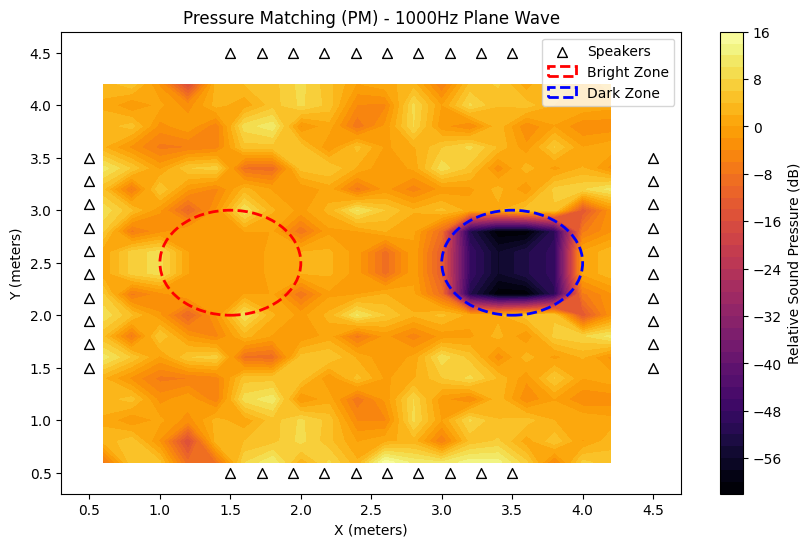

In [7]:
# Calc p
p_actual = H @ g
pressure_map = np.abs(p_actual).reshape(X.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(X, Y, 20 * np.log10(pressure_map.clip(-80, 40)), levels=50, cmap='inferno')
plt.colorbar(label="Relative Sound Pressure (dB)")

plt.scatter(all_speakers[0, :], all_speakers[1, :], color='white', edgecolors='black', label='Speakers', marker='^', s=50)

bright_circle = plt.Circle(bright_center, radius, color='red', fill=False, linestyle='--', linewidth=2, label='Bright Zone')
plt.gca().add_patch(bright_circle)
dark_circle = plt.Circle(dark_center, radius, color='blue', fill=False, linestyle='--', linewidth=2, label='Dark Zone')
plt.gca().add_patch(dark_circle)

plt.title(f"Pressure Matching (PM) - {target_freq}Hz Plane Wave")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.legend()
plt.show()